<a href="https://colab.research.google.com/github/chrishan-92/ComputerVisionAssignment01/blob/Master/Comp_VIsion_Assigment_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


/tmp/ipython-input-1904395918.py:26: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(out_arr, mode="L").save(output_path)


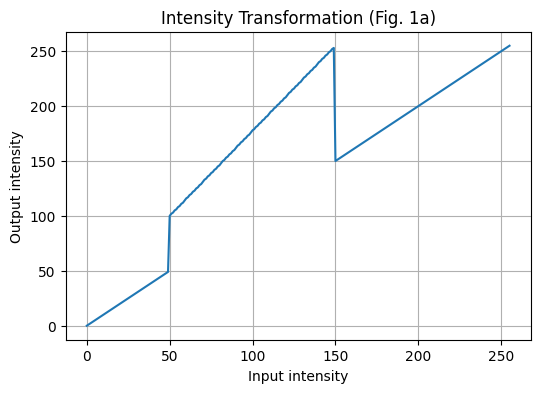

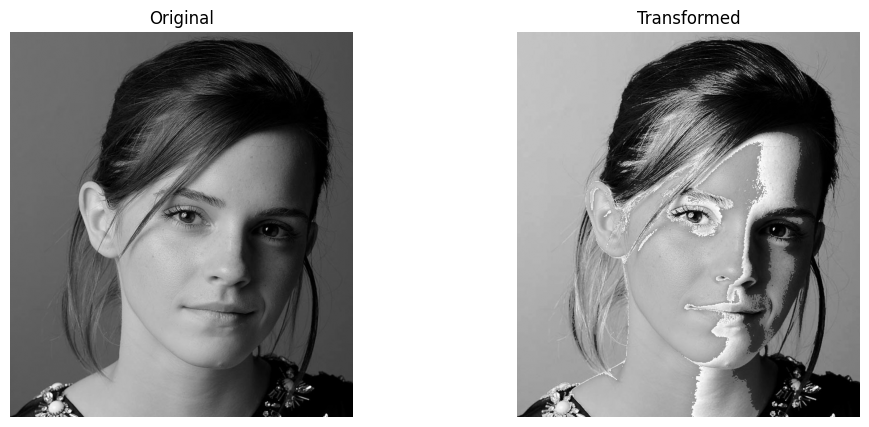

✅ Saved: /content/drive/MyDrive/Computer Vision/Assignment 1/emma_transformed.jpg


In [2]:
from PIL import Image
import numpy as np
import os, matplotlib.pyplot as plt

# ----- Fig. 1a LUT -----
def build_fig1a_lut():
    lut = np.zeros(256, dtype=np.uint8)
    # 0..49 : y = x
    for x in range(0, 50):
        lut[x] = x
    # 50..149 : line 50→100, 150→255
    for x in range(50, 150):
        y = 100 + 1.55 * (x - 50)
        lut[x] = np.clip(int(round(y)), 0, 255)
    # 150..255 : y = x (discontinuity at 150 handled by jump)
    for x in range(150, 256):
        lut[x] = x
    return lut

def apply_lut_to_image(image_path, output_path, lut=None):
    if lut is None:
        lut = build_fig1a_lut()
    img = Image.open(image_path).convert("L")
    arr = np.array(img, dtype=np.uint8)
    out_arr = lut[arr]
    Image.fromarray(out_arr, mode="L").save(output_path)
    return arr, out_arr

# ----- Your path -----
in_path = "/content/drive/MyDrive/Computer Vision/Assignment 1/emma.jpg"
root, ext = os.path.splitext(in_path)
out_path = root + "_transformed" + ext

# ----- Run -----
lut = build_fig1a_lut()
orig, trans = apply_lut_to_image(in_path, out_path, lut=lut)

# ----- Show curve + images -----
x = np.arange(256)
plt.figure(figsize=(6,4))
plt.plot(x, lut); plt.grid(True)
plt.title("Intensity Transformation (Fig. 1a)")
plt.xlabel("Input intensity"); plt.ylabel("Output intensity")
plt.show()

plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.imshow(orig, cmap="gray", vmin=0, vmax=255); plt.title("Original"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(trans, cmap="gray", vmin=0, vmax=255); plt.title("Transformed"); plt.axis("off")
plt.show()

print("✅ Saved:", out_path)